# CNN-LSTM — Human Activity Recognition
**CS3244 Group 32 | Nabil Rakaiza Abror**

Dataset: Smartphone-Based Recognition of Human Activities and Postural Transitions (UCI)

This file contains the source code for evaluating a **CNN-LSTM** framework using raw dataset. It documents several experiments conducted to optimize performance under different configurations:
* **Baseline Model:** A standard CNN-LSTM architecture without additional modifications.
* **Class Weighting:** Adjusting loss function weights as an alternative strategy for imbalanced data.
* **SMOTE Integration:** Implementing Synthetic Minority Over-sampling Technique to address class imbalance.

### Import Libraries

In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, jaccard_score,
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

### Configuration

In [2]:
# ── Dataset path ────────────────────────────────────────────────────────────
DATA_DIR   = "data/RawData"   # <-- change to your local folder

# ── Segmentation ────────────────────────────────────────────────────────────
WINDOW_SIZE = 128             # Samples per window  (~2.56 s at 50 Hz)
OVERLAP     = 0.5             # 50 % step overlap between consecutive windows

# ── Training ────────────────────────────────────────────────────────────────
BATCH_SIZE  = 64
EPOCHS      = 100
LR          = 1e-3

# ── Subject-based train / test split ────────────────────────────────────────
TEST_USERS  = [27, 28, 29, 30]   # Held-out subjects; fall back to 80/20 if missing

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED        = 42

# ── Imbalance-handling flags (set one combination per run) ───────────────────
USE_SMOTE         = False   # Apply SMOTE oversampling on the training set
USE_CLASS_WEIGHTS = True    # Use balanced class weights in CrossEntropyLoss

# ── Activity label map (UCI HAR — full 12-class protocol) ───────────────────
ACTIVITY_LABELS = {
    1: "WALKING",       2: "WALKING_UP",    3: "WALKING_DOWN",
    4: "SITTING",       5: "STANDING",      6: "LAYING",
    7: "STAND_TO_SIT",  8: "SIT_TO_STAND",  9: "SIT_TO_LIE",
    10: "LIE_TO_SIT",  11: "STAND_TO_LIE", 12: "LIE_TO_STAND",
}

# ── Device ──────────────────────────────────────────────────────────────────
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"SMOTE  : {USE_SMOTE}   |   Class weights : {USE_CLASS_WEIGHTS}")


Device : cpu
SMOTE  : False   |   Class weights : True


### Data Loading

Reads every `acc_expXX_userYY.txt` / `gyro_expXX_userYY.txt` pair and aligns
them with the activity labels from `labels.txt`.  
Each record stores the 6-channel signal (acc + gyro) and a per-sample integer
label (0 = unlabelled transition).

In [3]:
def load_raw_signals(data_dir):
    """
    Load all accelerometer + gyroscope files and merge with activity labels.

    Returns
    -------
    records : list of dict
        Each dict has keys:
          'signal' : np.ndarray (N, 6)  — [acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z]
          'labels' : np.ndarray (N,)    — integer activity IDs (0 = unlabelled)
          'user'   : int
          'exp'    : int
    """
    labels_path = os.path.join(data_dir, "labels.txt")
    label_table = np.loadtxt(labels_path, dtype=int)
    # Columns: exp_id, user_id, activity_id, start_sample (1-based), end_sample (1-based)

    # Index label rows by (exp, user) for O(1) lookup
    label_index = defaultdict(list)
    for row in label_table:
        label_index[(row[0], row[1])].append(row)

    records = []
    acc_files = sorted(glob.glob(os.path.join(data_dir, "acc_exp*_user*.txt")))

    for acc_path in acc_files:
        basename = os.path.basename(acc_path)
        parts    = basename.replace(".txt", "").split("_")
        exp_id   = int(parts[1].replace("exp", ""))
        user_id  = int(parts[2].replace("user", ""))

        gyro_path = os.path.join(data_dir, f"gyro_exp{exp_id:02d}_user{user_id:02d}.txt")
        if not os.path.exists(gyro_path):
            print(f"  [SKIP] Missing gyro for exp{exp_id:02d}_user{user_id:02d}")
            continue

        acc    = np.loadtxt(acc_path,  dtype=np.float32)   # (N, 3)
        gyro   = np.loadtxt(gyro_path, dtype=np.float32)   # (N, 3)
        signal = np.concatenate([acc, gyro], axis=1)        # (N, 6)

        # Build a per-sample label array; 0 marks unlabelled / transition regions
        n_samples     = signal.shape[0]
        sample_labels = np.zeros(n_samples, dtype=int)

        for row in label_index.get((exp_id, user_id), []):
            _, _, activity, start, end = row
            sample_labels[start - 1 : end] = activity   # labels.txt is 1-indexed

        records.append({
            "signal": signal,
            "labels": sample_labels,
            "user":   user_id,
            "exp":    exp_id,
        })

    print(f"Loaded {len(records)} experiment files.")
    return records


### Sliding Window Segmentation

Slices every continuous recording into fixed-length windows with configurable overlap.  
A majority vote over the window's sample labels assigns the window's class,
and windows that contain any unlabelled samples (label = 0) are discarded.

In [4]:
def sliding_windows(records, window_size=128, overlap=0.5):
    """
    Segment recordings into fixed-size windows.

    Parameters
    ----------
    records     : list of dicts from load_raw_signals()
    window_size : int   — number of samples per window
    overlap     : float — fractional overlap between consecutive windows

    Returns
    -------
    X     : np.ndarray (N, window_size, 6)
    y     : np.ndarray (N,)               — majority-vote activity labels
    users : np.ndarray (N,)               — subject ID per window
    """
    step = int(window_size * (1 - overlap))
    X_list, y_list, user_list = [], [], []

    for rec in records:
        signal = rec["signal"]
        labels = rec["labels"]
        user   = rec["user"]
        n      = len(signal)

        for start in range(0, n - window_size + 1, step):
            end        = start + window_size
            window_lbl = labels[start:end]

            # Discard windows with any unlabelled sample (transition region)
            if np.any(window_lbl == 0):
                continue

            # Majority vote: pick the most frequent activity in the window
            counts   = np.bincount(window_lbl, minlength=13)
            majority = np.argmax(counts[1:]) + 1   # counts[0] is class 0

            X_list.append(signal[start:end])
            y_list.append(majority)
            user_list.append(user)

    X     = np.stack(X_list)        # (N, 128, 6)
    y     = np.array(y_list)        # (N,)
    users = np.array(user_list)     # (N,)
    return X, y, users


### Normalization

Standard-scales each of the 6 sensor channels independently.  
The scaler is **fit on training data only** and applied to both splits,
preventing data leakage from the test set.


In [5]:
def normalise(X_train, X_test):
    """
    Z-score normalise all 6 channels using training-set statistics.

    The data is reshaped to (N*T, C) for the scaler, then restored
    to (N, T, C) — operating per-channel across all time steps.
    """
    N_tr, W, C = X_train.shape
    scaler = StandardScaler()

    # Flatten time dimension so scaler sees each channel as a feature column
    X_train_2d = X_train.reshape(-1, C)
    X_test_2d  = X_test.reshape(-1, C)

    X_train_2d = scaler.fit_transform(X_train_2d)   # fit + transform on train
    X_test_2d  = scaler.transform(X_test_2d)         # transform only on test

    return X_train_2d.reshape(N_tr, W, C), X_test_2d.reshape(-1, W, C)


### SMOTE Sampling (For Approach 3)

SMOTE synthesises new minority-class windows in the feature space by
interpolating between existing samples.  
It is applied **only to the training set** after normalisation — the test
set is never touched.


In [6]:
def apply_smote(X_train, y_train):
    """
    Apply SMOTE oversampling to balance the training set.

    The 3-D windows are flattened to 2-D for SMOTE, then reshaped back.
    k_neighbors is capped at (smallest_class_count - 1) to avoid errors
    on very small minority classes.

    Returns
    -------
    X_res : np.ndarray (N_resampled, W, C)
    y_res : np.ndarray (N_resampled,)
    """
    n, w, c = X_train.shape
    X_flat  = X_train.reshape(n, w * c)

    counts = dict(zip(*np.unique(y_train, return_counts=True)))
    print("  Class distribution BEFORE SMOTE:")
    for cls, cnt in sorted(counts.items()):
        print(f"    {ACTIVITY_LABELS.get(cls, str(cls)):15s}: {cnt:4d} windows")

    # Ensure k_neighbors < smallest class count to avoid SMOTE errors
    min_count = min(counts.values())
    k = min(5, min_count - 1)
    if k < 1:
        print("  [WARN] Too few samples for SMOTE — skipping.")
        return X_train, y_train

    sm     = SMOTE(random_state=SEED, k_neighbors=k)
    X_res, y_res = sm.fit_resample(X_flat, y_train)
    X_res  = X_res.reshape(-1, w, c)

    counts_after = dict(zip(*np.unique(y_res, return_counts=True)))
    print("  Class distribution AFTER SMOTE:")
    for cls, cnt in sorted(counts_after.items()):
        print(f"    {ACTIVITY_LABELS.get(cls, str(cls)):15s}: {cnt:4d} windows")
    print(f"  Windows: {n} → {len(X_res)}")
    return X_res, y_res


### PyTorch Dataset

Wraps numpy arrays in a `torch.utils.data.Dataset`.  
Conv1d in PyTorch expects `(batch, channels, length)`, so the data is
permuted from `(N, T, C)` → `(N, C, T)` here.  
Activity IDs are remapped to contiguous 0-based indices to match
`CrossEntropyLoss` requirements.


In [7]:
class HARDataset(Dataset):
    """
    PyTorch Dataset for UCI HAR sliding-window data.

    Attributes
    ----------
    X            : Tensor (N, C, T)  — sensor channels as Conv1d input
    y            : Tensor (N,)       — 0-based class indices
    num_classes  : int
    unique_classes : list            — original activity IDs in sorted order
    class_map    : dict              — original_id → 0-based index
    """

    def __init__(self, X, y):
        # Permute to (N, C, T) for Conv1d compatibility
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)

        # Build a stable mapping: sorted activity IDs → [0, 1, 2, ...]
        unique_classes     = sorted(np.unique(y))
        self.class_map     = {c: i for i, c in enumerate(unique_classes)}
        self.y             = torch.tensor([self.class_map[c] for c in y], dtype=torch.long)
        self.num_classes   = len(unique_classes)
        self.unique_classes = unique_classes

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


### CNN-LSTM Model

**Architecture overview:**

```
Input (B, 6, 128)
   │
   ▼  ── CNN Block ──────────────────────────────────────────
   │   Conv1d(6→64) → BN → ReLU → Conv1d(64→64) → BN → ReLU
   │   MaxPool1d(2)   → Dropout                       [B, 64, 64]
   │   Conv1d(64→128) → BN → ReLU
   │   MaxPool1d(2)   → Dropout                       [B, 128, 32]
   │
   ▼  ── LSTM Block ─────────────────────────────────────────
   │   Permute → (B, 32, 128)
   │   Bi-LSTM(128 hidden, 2 layers)                  [B, 32, 128]
   │   Take last timestep                             [B, 128]
   │
   ▼  ── Classifier Head ────────────────────────────────────
       Dropout → Linear(128→64) → ReLU → Linear(64→n_classes)
```

In [8]:
class CNNLSTM(nn.Module):
    """
    Hybrid CNN-LSTM network for time-series activity recognition.

    The CNN front-end extracts local temporal features and reduces the
    sequence length before feeding into the LSTM, which captures long-range
    temporal dependencies.  The final hidden state is projected to class logits.

    Parameters
    ----------
    n_channels   : int  — number of input sensor channels (6 for acc+gyro)
    n_classes    : int  — number of activity classes
    cnn_filters  : int  — base number of CNN filters (doubles in the 2nd block)
    lstm_hidden  : int  — LSTM hidden state size
    lstm_layers  : int  — number of stacked LSTM layers
    dropout      : float — dropout rate applied after pooling and in the head
    """

    def __init__(self, n_channels=6, n_classes=12,
                 cnn_filters=64, lstm_hidden=128, lstm_layers=2, dropout=0.3):
        super().__init__()

        # ── CNN block: extract local temporal patterns ──────────────────────
        self.cnn = nn.Sequential(
            nn.Conv1d(n_channels, cnn_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_filters),
            nn.ReLU(),
            nn.Conv1d(cnn_filters, cnn_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_filters),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),        # 128 → 64 timesteps
            nn.Dropout(dropout),

            nn.Conv1d(cnn_filters, cnn_filters * 2, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_filters * 2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),        # 64 → 32 timesteps
            nn.Dropout(dropout),
        )

        # ── LSTM block: model temporal dynamics across CNN feature maps ─────
        self.lstm = nn.LSTM(
            input_size=cnn_filters * 2,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0,
            bidirectional=False,
        )

        # ── Classifier head: map LSTM output to class logits ────────────────
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        # x: (batch, channels, time)
        x = self.cnn(x)             # → (batch, cnn_filters*2, 32)
        x = x.permute(0, 2, 1)     # → (batch, 32, cnn_filters*2) for LSTM
        x, _ = self.lstm(x)         # → (batch, 32, lstm_hidden)
        x = x[:, -1, :]             # Take the last timestep representation
        return self.classifier(x)   # → (batch, n_classes)


### Training & Evaluation Loops

- **`train_epoch`** — one pass over the training DataLoader with gradient clipping.
- **`eval_epoch`** — inference pass that also collects raw logits (needed for ROC-AUC).


In [9]:
def train_epoch(model, loader, criterion, optimizer):
    """One full training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()

        # Gradient clipping prevents exploding gradients in the LSTM
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct    += (out.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    """
    Evaluation pass.

    Returns
    -------
    avg_loss  : float
    accuracy  : float
    preds     : np.ndarray (N,)    — predicted class indices
    true      : np.ndarray (N,)    — ground-truth class indices
    probs     : np.ndarray (N, C)  — softmax probabilities (for ROC-AUC)
    """
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_true, all_probs = [], [], []

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        logits = model(X_batch)
        loss   = criterion(logits, y_batch)

        probs  = F.softmax(logits, dim=1)
        preds  = logits.argmax(1)

        total_loss += loss.item() * len(y_batch)
        correct    += (preds == y_batch).sum().item()
        total      += len(y_batch)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y_batch.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return (
        total_loss / total,
        correct / total,
        np.array(all_preds),
        np.array(all_true),
        np.array(all_probs),
    )


### Visualization Functions

In [10]:
# ── Raw signal visualisation ────────────────────────────────────────────────

def plot_sample_signals(records):
    """Plot a 10-second snippet of acc and gyro signals with activity shading."""
    rec    = records[0]
    signal = rec["signal"]
    labels = rec["labels"]

    # Find the first labelled region and show 500 samples (~10 s at 50 Hz)
    mask  = labels > 0
    start = np.argmax(mask)
    end   = min(start + 500, len(signal))
    t     = np.arange(end - start) / 50.0   # seconds

    ch_names = ["Acc X", "Acc Y", "Acc Z", "Gyro X", "Gyro Y", "Gyro Z"]
    colors   = ["#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#f4a261", "#264653"]

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    fig.suptitle(
        f"Raw Signals — Exp {rec['exp']:02d}  User {rec['user']:02d}",
        fontsize=13, fontweight="bold"
    )

    for i in range(3):
        axes[0].plot(t, signal[start:end, i], label=ch_names[i], color=colors[i], lw=0.9)
    axes[0].set_ylabel("Acceleration (g)")
    axes[0].legend(loc="upper right"); axes[0].grid(alpha=0.3)

    for i in range(3, 6):
        axes[1].plot(t, signal[start:end, i], label=ch_names[i], color=colors[i], lw=0.9)
    axes[1].set_ylabel("Angular velocity (rad/s)")
    axes[1].set_xlabel("Time (s)")
    axes[1].legend(loc="upper right"); axes[1].grid(alpha=0.3)

    # Shade background by activity segment
    prev_lbl, prev_s = labels[start], 0
    for j in range(1, end - start):
        curr = labels[start + j]
        if curr != prev_lbl or j == end - start - 1:
            if prev_lbl > 0:
                for ax in axes:
                    ax.axvspan(prev_s / 50.0, j / 50.0, alpha=0.08,
                               color=plt.cm.tab20(prev_lbl / 12.0))
            prev_lbl, prev_s = curr, j

    plt.tight_layout()
    plt.show()


# ── Class distribution (SMOTE comparison) ──────────────────────────────────

def plot_class_distribution(y_before, y_after, title_suffix=""):
    """Bar chart comparing window counts before and after SMOTE."""
    all_cls = sorted(set(y_before) | set(y_after))
    names   = [ACTIVITY_LABELS.get(c, str(c)) for c in all_cls]
    before  = [np.sum(y_before == c) for c in all_cls]
    after   = [np.sum(y_after  == c) for c in all_cls]

    x = np.arange(len(all_cls))
    w = 0.35

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - w/2, before, w, label="Before SMOTE", color="#4C72B0", alpha=0.85)
    ax.bar(x + w/2, after,  w, label="After SMOTE",  color="#55A868", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Number of Windows")
    ax.set_title(f"Training-Set Class Distribution — Before vs After SMOTE {title_suffix}",
                 fontsize=13, fontweight="bold")
    ax.legend(); ax.grid(axis="y", alpha=0.3)

    for i, (b, a) in enumerate(zip(before, after)):
        ax.text(i - w/2, b + 0.5, str(b), ha="center", fontsize=7, color="#1a1a2e")
        ax.text(i + w/2, a + 0.5, str(a), ha="center", fontsize=7, color="#1b4332")

    plt.tight_layout()
    plt.show()


# ── Training curves ─────────────────────────────────────────────────────────

def plot_training_curves(history, title_suffix=""):
    """Plot training and validation loss + accuracy over epochs."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"CNN-LSTM Training History — UCI HAR  {title_suffix}",
                 fontsize=14, fontweight="bold")

    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], label="Train", color="#4C72B0", lw=2)
    axes[0].plot(epochs, history["val_loss"],   label="Val",   color="#DD8452", lw=2)
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, [a * 100 for a in history["train_acc"]], label="Train", color="#4C72B0", lw=2)
    axes[1].plot(epochs, [a * 100 for a in history["val_acc"]],   label="Val",   color="#DD8452", lw=2)
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_ylim(0, 100); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ── Confusion matrix ────────────────────────────────────────────────────────

def plot_confusion_matrix(y_true, y_pred, class_names, title_suffix=""):
    """Side-by-side heatmaps: raw counts and row-normalised recall."""
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    labels = np.unique(np.concatenate((y_true, y_pred)))

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f"CNN-LSTM Confusion Matrix — UCI HAR  {title_suffix}",
                 fontsize=14, fontweight="bold")

    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ["d", ".2f"],
        ["Raw Counts", "Normalised (Recall)"]
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=labels, yticklabels=labels,
                    ax=ax, linewidths=0.5, annot_kws={"size": 8})
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    plt.show()


# ── MIoU ────────────────────────────────────────────────────────────────────

def plot_miou(y_true, y_pred, class_names, title_suffix=""):
    """
    Compute and plot per-class IoU (Jaccard score) and their macro mean (MIoU).

    IoU per class = TP / (TP + FP + FN), consistent with semantic-segmentation
    practice applied to classification windows.
    """
    n_cls  = len(class_names)
    labels = list(range(n_cls))

    # Per-class IoU using sklearn's Jaccard score
    iou_per_class = jaccard_score(y_true, y_pred, labels=labels, average=None,
                                  zero_division=0)
    miou = np.mean(iou_per_class)

    fig, ax = plt.subplots(figsize=(14, 5))
    colors  = ["#4C72B0" if v >= miou else "#DD8452" for v in iou_per_class]
    bars    = ax.bar(class_names, iou_per_class * 100, color=colors, edgecolor="white")

    # Horizontal line at MIoU
    ax.axhline(miou * 100, color="#c0392b", lw=2, ls="--",
               label=f"MIoU = {miou * 100:.1f} %")

    # Annotate bars
    for bar, v in zip(bars, iou_per_class):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f"{v * 100:.1f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(range(n_cls))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("IoU (%)")
    ax.set_ylim(0, 110)
    ax.set_title(f"Per-Class IoU & MIoU — CNN-LSTM on UCI HAR  {title_suffix}",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f"  MIoU : {miou * 100:.2f} %")
    for name, iou in zip(class_names, iou_per_class):
        print(f"    {name:15s}: {iou * 100:.1f} %")


# ── ROC-AUC (One-vs-Rest, per class) ───────────────────────────────────────

def plot_roc_auc(y_true, y_probs, class_names, title_suffix=""):
    """
    Plot One-vs-Rest ROC curves for every class in a single figure.

    y_true  : 1-D integer class indices (0-based)
    y_probs : 2-D array (N, n_classes) — softmax probabilities from eval_epoch
    """
    n_cls  = len(class_names)
    # Binarise ground truth for OvR evaluation
    y_bin  = label_binarize(y_true, classes=list(range(n_cls)))

    # Colour palette
    palette = plt.cm.tab20(np.linspace(0, 1, n_cls))

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.50)")

    for i, (name, color) in enumerate(zip(class_names, palette)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=1.5, color=color,
                label=f"{name}  (AUC = {roc_auc:.3f})")

    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate",  fontsize=12)
    ax.set_title(f"One-vs-Rest ROC Curves per Class — CNN-LSTM  {title_suffix}",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=8, loc="lower right", ncol=2)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ── Per-class precision / recall / F1 ──────────────────────────────────────

def plot_per_class_metrics(y_true, y_pred, class_names, title_suffix=""):
    """Grouped bar chart of per-class precision, recall, and F1-score."""
    # Generate classification report as a dict (keyed by class name)
    report = classification_report(
        y_true, y_pred,
        # labels=list(range(len(class_names))),
        # target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    precision = [report[c]["precision"] * 100 for c in class_names]
    recall    = [report[c]["recall"]    * 100 for c in class_names]
    f1        = [report[c]["f1-score"]  * 100 for c in class_names]

    x = np.arange(len(class_names))
    w = 0.25

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.bar(x - w, precision, w, label="Precision", color="#4C72B0")
    ax.bar(x,     recall,    w, label="Recall",    color="#DD8452")
    ax.bar(x + w, f1,        w, label="F1-Score",  color="#55A868")

    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Score (%)")
    ax.set_ylim(0, 115)
    ax.set_title(f"Per-Class Metrics — CNN-LSTM on UCI HAR  {title_suffix}",
                 fontsize=13, fontweight="bold")
    ax.legend(); ax.grid(axis="y", alpha=0.3)

    # Annotate F1 values on top of the F1 bars
    for i, v in enumerate(f1):
        ax.text(x[i] + w, v + 1.5, f"{v:.1f}", ha="center", fontsize=7, color="#2d6a4f")

    plt.tight_layout()
    plt.show()


### Shared Training Pipeline

`run_pipeline` encapsulates the full train-evaluate-visualise workflow so it
can be called for each of the three approaches with only the flags changing.


In [11]:
def run_pipeline(use_smote=False, use_class_weights=False, records=None,
                 X=None, y=None, users=None, unique_classes=None,
                 n_classes=None, class_names=None,
                 X_train=None, y_train=None, X_test=None, y_test=None,
                 title_suffix="", activity_label = ACTIVITY_LABELS):
    """
    Full training and evaluation pipeline for one experimental configuration.

    Parameters
    ----------
    use_smote         : bool — apply SMOTE to the training set
    use_class_weights : bool — use balanced class weights in the loss
    title_suffix      : str  — appended to plot titles for identification

    Pre-computed data arguments (X, y, users, splits) are accepted so that
    data loading and segmentation are shared across all three runs.
    """

    print(f"\n{'='*70}")
    print(f"  Running: {title_suffix}")
    print(f"  SMOTE={use_smote}  |  Class weights={use_class_weights}")
    print(f"{'='*70}\n")

    X_tr = X_train.copy()
    y_tr = y_train.copy()

    # ── Optional: SMOTE oversampling ──────────────────────────────────────
    y_tr_before = y_tr.copy()
    if use_smote:
        print("[SMOTE] Applying oversampling on training set ...")
        X_tr, y_tr = apply_smote(X_tr, y_tr)
        plot_class_distribution(y_tr_before, y_tr, title_suffix=title_suffix)
    else:
        print("[SMOTE] Disabled — using original class distribution.")

    # ── Optional: balanced class weights ──────────────────────────────────
    if use_class_weights:
        weights       = compute_class_weight("balanced",
                                             classes=np.unique(y_tr), y=y_tr)
        weight_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
        print(f"[Loss] Class weights: {[f'{w:.2f}' for w in weights]}")
    else:
        weight_tensor = None

    # ── Build DataLoaders ─────────────────────────────────────────────────
    train_ds     = HARDataset(X_tr,    y_tr)
    test_ds      = HARDataset(X_test,  y_test)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # ── Build model ───────────────────────────────────────────────────────
    model = CNNLSTM(n_channels=6, n_classes=n_classes).to(device)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[Model] Trainable parameters: {total_params:,}")

    criterion = nn.CrossEntropyLoss(weight=weight_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    # ── Training loop ─────────────────────────────────────────────────────
    print(f"[Train] Starting {EPOCHS}-epoch training ...")
    history      = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    best_state   = None

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, _, _, _ = eval_epoch(model, test_loader, criterion)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        # Keep a snapshot of the best checkpoint in memory (no disk I/O needed)
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{EPOCHS} | "
                  f"Train loss {tr_loss:.4f} acc {tr_acc*100:.1f}% | "
                  f"Val loss {vl_loss:.4f} acc {vl_acc*100:.1f}%")

    # ── Restore best weights and final evaluation ─────────────────────────
    model.load_state_dict(best_state)
    _, final_acc, preds_idx, true_idx, probs = eval_epoch(model, test_loader, criterion)
    print(f"\n  ✓ Best Val Accuracy : {best_val_acc * 100:.2f} %")
    print(f"  ✓ Final Test Accuracy: {final_acc * 100:.2f} %")

    # Remap 0-based indices back to human-readable class names for the report
    preds_named = [activity_label[p + 1] for p in preds_idx]
    true_named  = [activity_label[t + 1] for t in true_idx]

    print("\n" + classification_report(true_named, preds_named, digits=4))

    # ── Inline visualisations ─────────────────────────────────────────────
    print("[Viz] Training curves ...")
    plot_training_curves(history, title_suffix=title_suffix)

    print("[Viz] Confusion matrix ...")
    plot_confusion_matrix(true_named, preds_named, class_names,
                          title_suffix=title_suffix)

    print("[Viz] MIoU ...")
    plot_miou(true_idx, preds_idx, class_names, title_suffix=title_suffix)

    print("[Viz] ROC-AUC (One-vs-Rest) ...")
    plot_roc_auc(true_idx, probs, class_names, title_suffix=title_suffix)

    print("[Viz] Per-class precision / recall / F1 ...")
    plot_per_class_metrics(true_named, preds_named, class_names,
                           title_suffix=title_suffix)

    return {
        "history":       history,
        "best_val_acc":  best_val_acc,
        "final_acc":     final_acc,
        "preds":         preds_idx,
        "true":          true_idx,
        "probs":         probs,
        "class_names":   class_names,
    }


### Shared Data Preparation

Load, segment, split, and normalise once.  
The same splits are reused for all three approaches so results are
directly comparable.


[1/3] Loading raw signals ...
Loaded 61 experiment files.

[1b/3] Sample signal visualisation ...


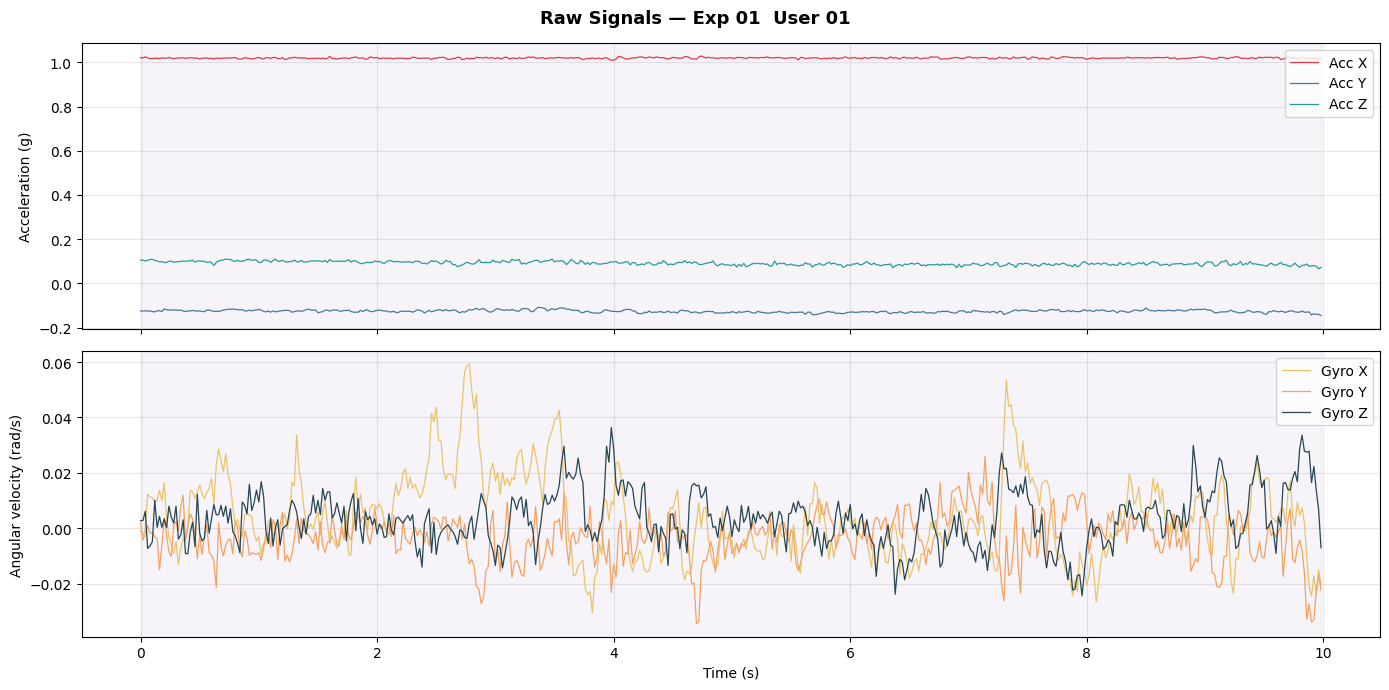


[2/3] Sliding-window segmentation ...
  Windows : (11621, 128, 6)   Labels : (11621,)
  Classes : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  Class names: ['WALKING', 'WALKING_UP', 'WALKING_DOWN', 'SITTING', 'STANDING', 'LAYING', 'STAND_TO_SIT', 'SIT_TO_STAND', 'SIT_TO_LIE', 'LIE_TO_SIT', 'STAND_TO_LIE', 'LIE_TO_STAND']

[3/3] Train / test split ...
  Train: 9973 windows | Test: 1648 windows
  Normalising ...
  Done.


In [12]:
# ── Load raw signals ──────────────────────────────────────────────────────
print("[1/3] Loading raw signals ...")
records = load_raw_signals(DATA_DIR)

# ── Visualise a sample recording ─────────────────────────────────────────
print("\n[1b/3] Sample signal visualisation ...")
plot_sample_signals(records)

# ── Sliding-window segmentation ───────────────────────────────────────────
print("\n[2/3] Sliding-window segmentation ...")
X, y, users = sliding_windows(records, WINDOW_SIZE, OVERLAP)
print(f"  Windows : {X.shape}   Labels : {y.shape}")
print(f"  Classes : {sorted(np.unique(y))}")

unique_classes = sorted(np.unique(y))
n_classes      = len(unique_classes)
class_names    = [ACTIVITY_LABELS[c] for c in unique_classes]
print(f"  Class names: {class_names}")

# ── Subject-based train / test split (fallback to random 80/20) ─────────
print("\n[3/3] Train / test split ...")
test_mask  = np.isin(users, TEST_USERS)
train_mask = ~test_mask

if test_mask.sum() == 0:
    print("  [INFO] Test users not found — falling back to random 80/20 stratified split.")
    from sklearn.model_selection import train_test_split
    idx = np.arange(len(X))
    tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=SEED, stratify=y)
    X_train_raw, y_train_raw = X[tr_idx], y[tr_idx]
    X_test_raw,  y_test_raw  = X[te_idx], y[te_idx]
else:
    X_train_raw, y_train_raw = X[train_mask], y[train_mask]
    X_test_raw,  y_test_raw  = X[test_mask],  y[test_mask]

print(f"  Train: {X_train_raw.shape[0]} windows | Test: {X_test_raw.shape[0]} windows")

# ── Normalise ─────────────────────────────────────────────────────────────
print("  Normalising ...")
X_train_norm, X_test_norm = normalise(X_train_raw, X_test_raw)
print("  Done.")


### Approach 1 — Baseline (No Class Imbalance Handling)

Standard cross-entropy loss with uniform class weights.  
Establishes a performance reference for comparing the other two strategies.



  Running: [Approach 1 — Baseline]
  SMOTE=False  |  Class weights=False

[SMOTE] Disabled — using original class distribution.
[Model] Trainable parameters: 312,012
[Train] Starting 100-epoch training ...
  Epoch   1/100 | Train loss 0.9032 acc 71.2% | Val loss 0.5260 acc 80.1%
  Epoch   5/100 | Train loss 0.2579 acc 90.4% | Val loss 0.3086 acc 90.5%
  Epoch  10/100 | Train loss 0.2068 acc 91.6% | Val loss 0.3005 acc 89.8%
  Epoch  15/100 | Train loss 0.1829 acc 92.4% | Val loss 0.3301 acc 90.8%
  Epoch  20/100 | Train loss 0.1735 acc 93.2% | Val loss 0.3054 acc 91.1%
  Epoch  25/100 | Train loss 0.1606 acc 93.2% | Val loss 0.3038 acc 90.5%
  Epoch  30/100 | Train loss 0.1466 acc 93.9% | Val loss 0.2786 acc 92.7%
  Epoch  35/100 | Train loss 0.1278 acc 94.9% | Val loss 0.3164 acc 92.2%
  Epoch  40/100 | Train loss 0.1165 acc 95.2% | Val loss 0.3043 acc 91.1%
  Epoch  45/100 | Train loss 0.1097 acc 95.5% | Val loss 0.3346 acc 91.5%
  Epoch  50/100 | Train loss 0.0991 acc 96.0% | Val l

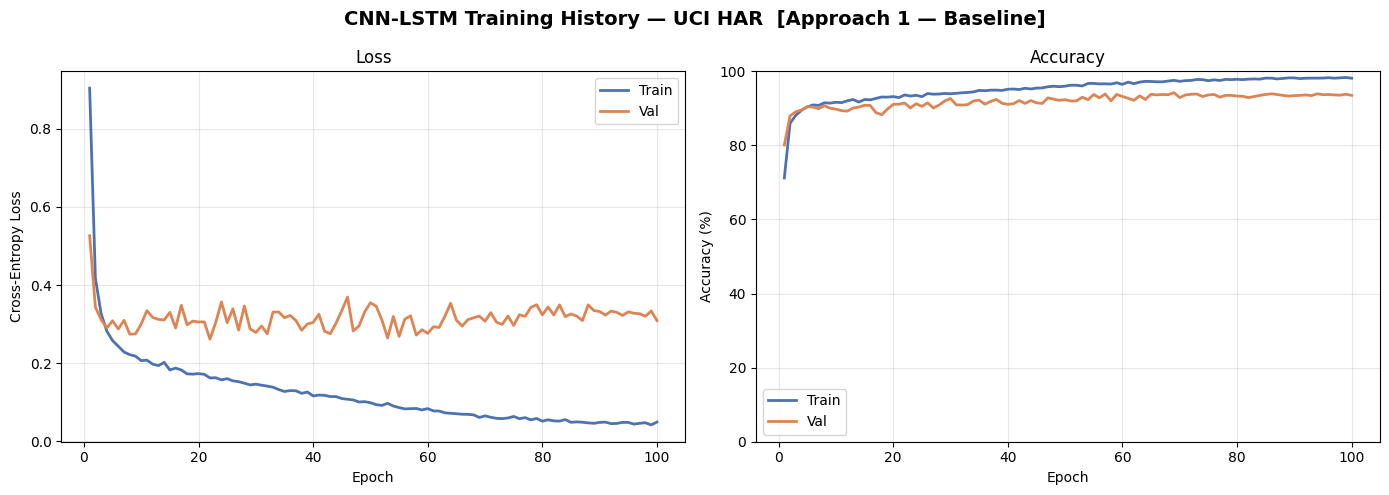

[Viz] Confusion matrix ...


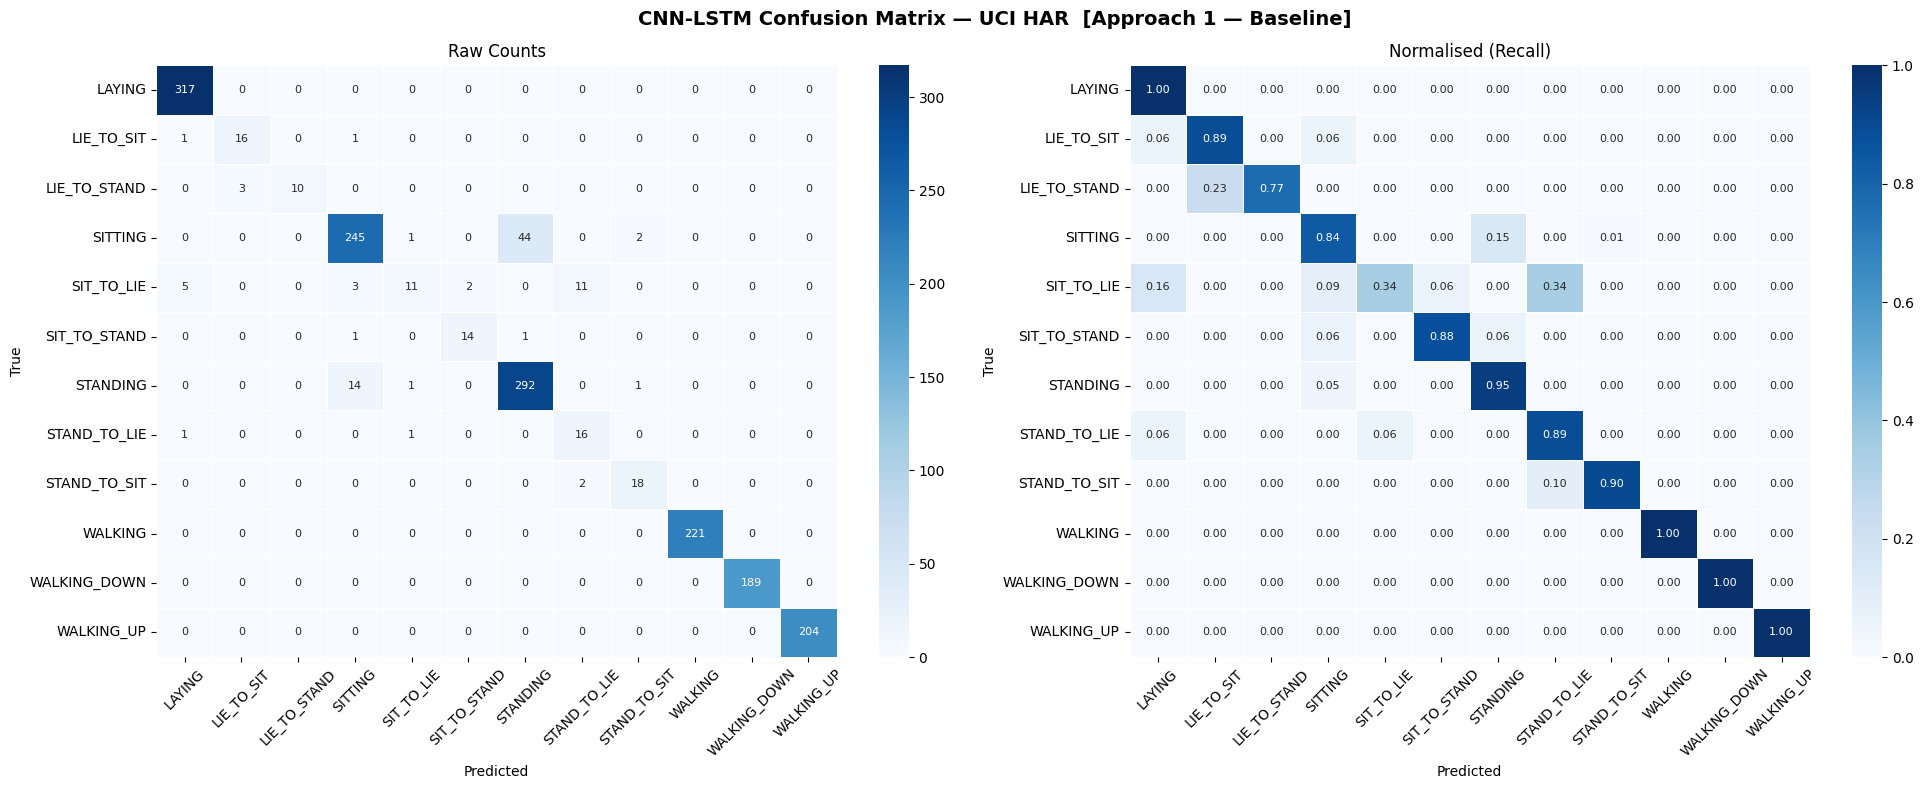

[Viz] MIoU ...


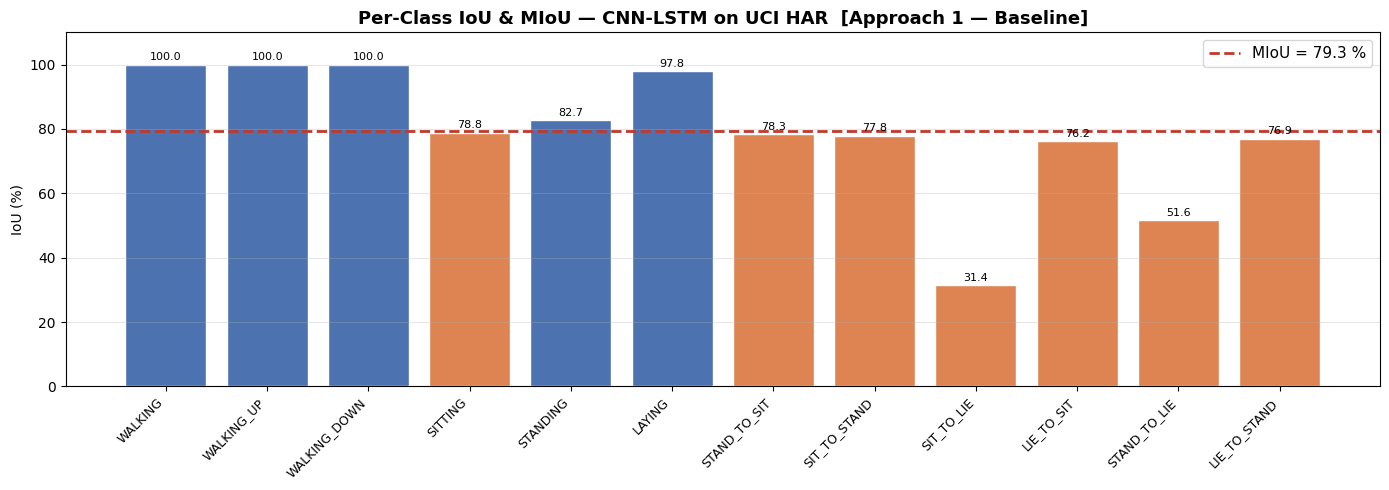

  MIoU : 79.29 %
    WALKING        : 100.0 %
    WALKING_UP     : 100.0 %
    WALKING_DOWN   : 100.0 %
    SITTING        : 78.8 %
    STANDING       : 82.7 %
    LAYING         : 97.8 %
    STAND_TO_SIT   : 78.3 %
    SIT_TO_STAND   : 77.8 %
    SIT_TO_LIE     : 31.4 %
    LIE_TO_SIT     : 76.2 %
    STAND_TO_LIE   : 51.6 %
    LIE_TO_STAND   : 76.9 %
[Viz] ROC-AUC (One-vs-Rest) ...


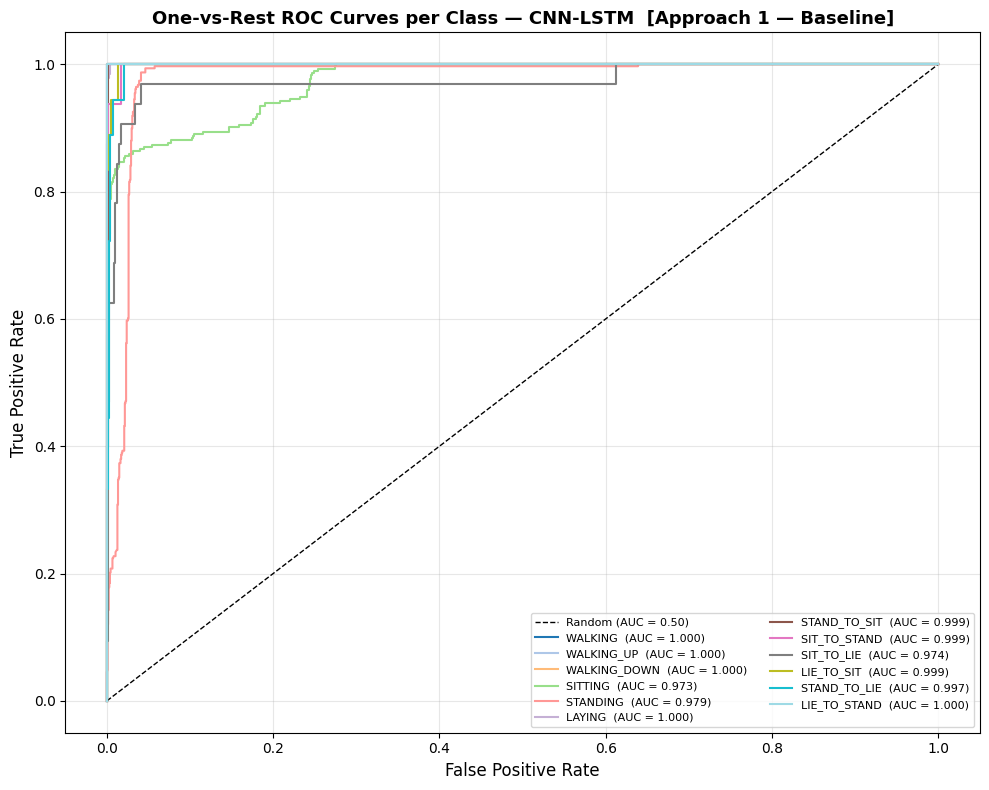

[Viz] Per-class precision / recall / F1 ...


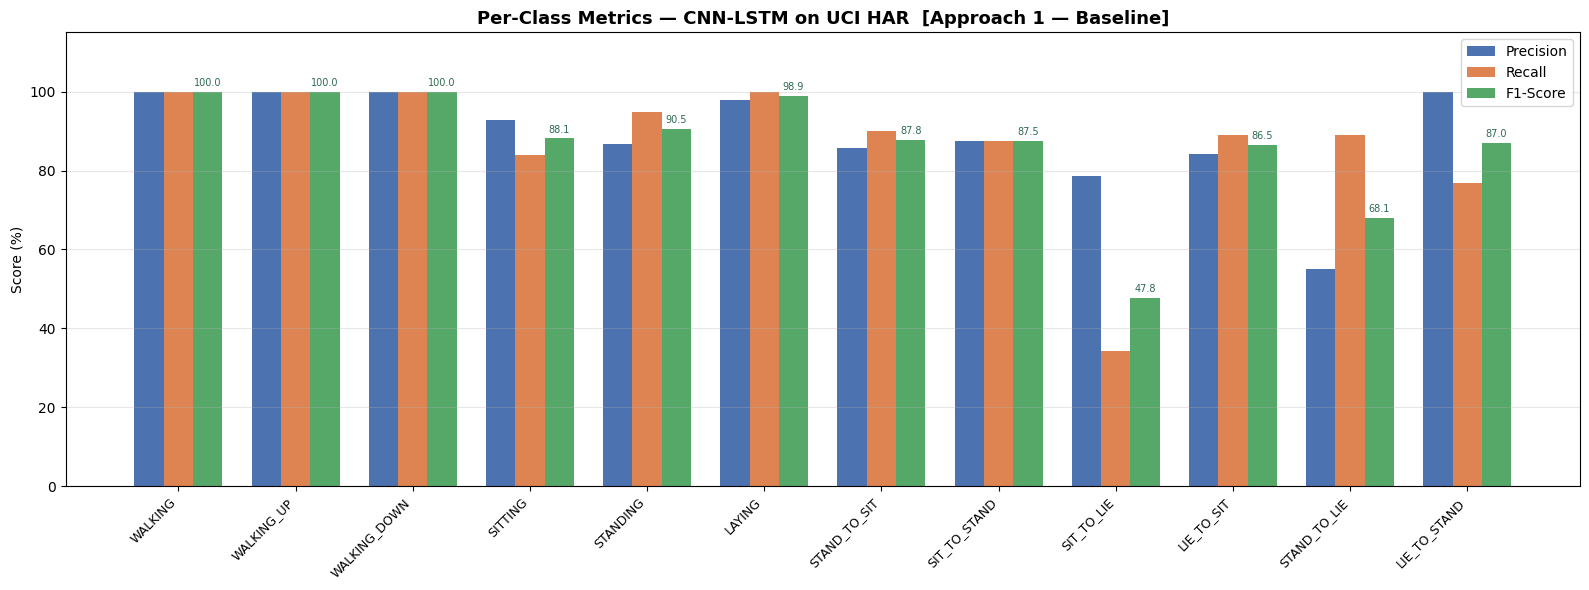

In [13]:
results_baseline = run_pipeline(
    use_smote=False,
    use_class_weights=False,
    X_train=X_train_norm, y_train=y_train_raw,
    X_test=X_test_norm,   y_test=y_test_raw,
    n_classes=n_classes,  class_names=class_names,
    title_suffix="[Approach 1 — Baseline]",
)


## Approach 2 — Class-Weighted Loss (No SMOTE)

Balanced class weights are computed from the training-set label distribution
and passed to `CrossEntropyLoss`.  Rare activities receive higher loss
penalties, nudging the model to attend to them without altering the data.


  Running: [Approach 2 — Class-Weighted Loss]
  SMOTE=False  |  Class weights=True

[SMOTE] Disabled — using original class distribution.
[Loss] Class weights: ['0.58', '0.66', '0.74', '0.49', '0.47', '0.45', '6.20', '7.99', '5.16', '5.47', '4.07', '8.84']
[Model] Trainable parameters: 312,012
[Train] Starting 100-epoch training ...
  Epoch   1/100 | Train loss 1.5022 acc 53.0% | Val loss 0.8748 acc 72.9%
  Epoch   5/100 | Train loss 0.4978 acc 88.4% | Val loss 0.4457 acc 88.9%
  Epoch  10/100 | Train loss 0.3737 acc 90.6% | Val loss 0.4689 acc 90.1%
  Epoch  15/100 | Train loss 0.3282 acc 91.6% | Val loss 0.4499 acc 91.2%
  Epoch  20/100 | Train loss 0.2949 acc 92.1% | Val loss 0.4679 acc 91.0%
  Epoch  25/100 | Train loss 0.2602 acc 92.6% | Val loss 0.4380 acc 91.2%
  Epoch  30/100 | Train loss 0.2183 acc 93.0% | Val loss 0.5329 acc 91.8%
  Epoch  35/100 | Train loss 0.2167 acc 93.5% | Val loss 0.4534 acc 89.9%
  Epoch  40/100 | Train loss 0.1978 acc 93.7% | Val loss 0.5129 acc 90.2

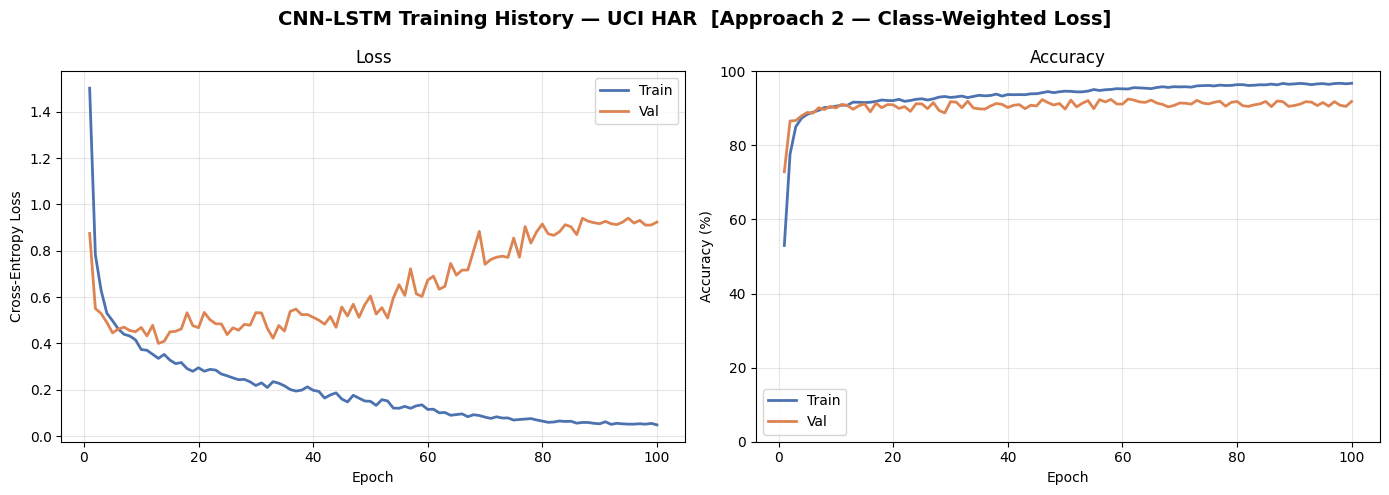

[Viz] Confusion matrix ...


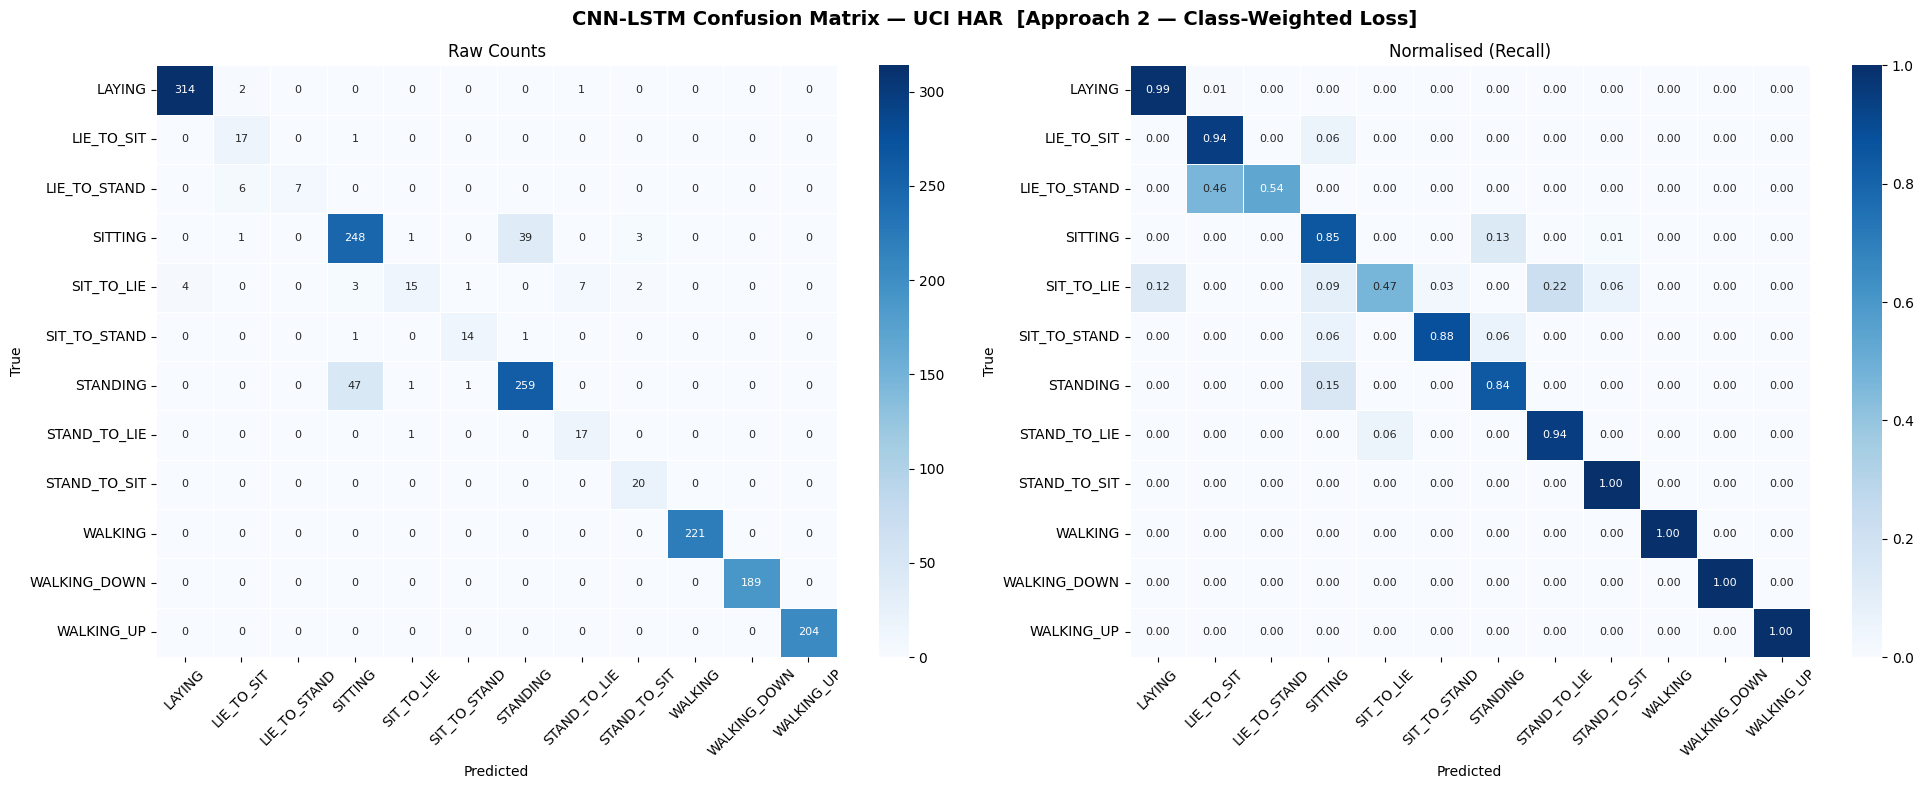

[Viz] MIoU ...


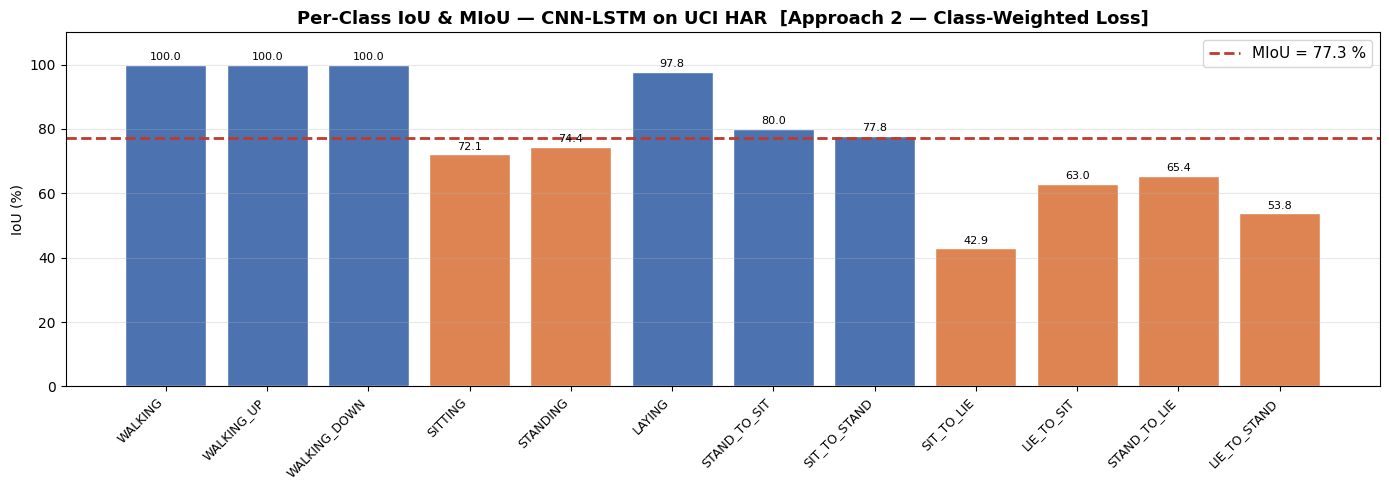

  MIoU : 77.26 %
    WALKING        : 100.0 %
    WALKING_UP     : 100.0 %
    WALKING_DOWN   : 100.0 %
    SITTING        : 72.1 %
    STANDING       : 74.4 %
    LAYING         : 97.8 %
    STAND_TO_SIT   : 80.0 %
    SIT_TO_STAND   : 77.8 %
    SIT_TO_LIE     : 42.9 %
    LIE_TO_SIT     : 63.0 %
    STAND_TO_LIE   : 65.4 %
    LIE_TO_STAND   : 53.8 %
[Viz] ROC-AUC (One-vs-Rest) ...


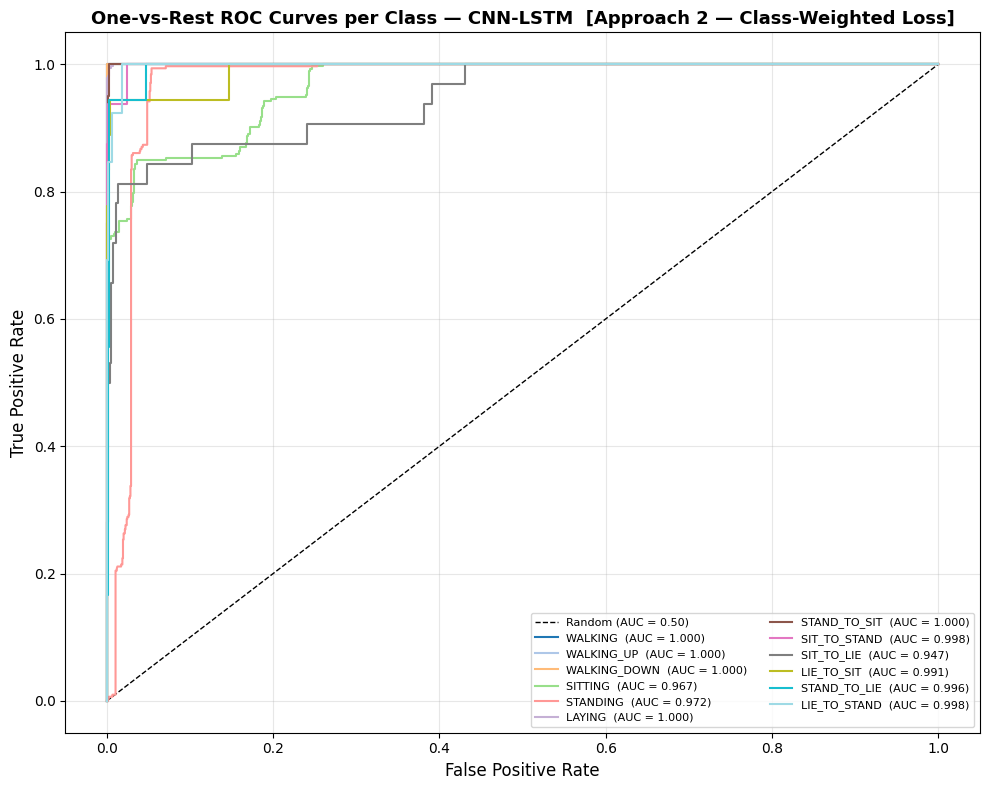

[Viz] Per-class precision / recall / F1 ...


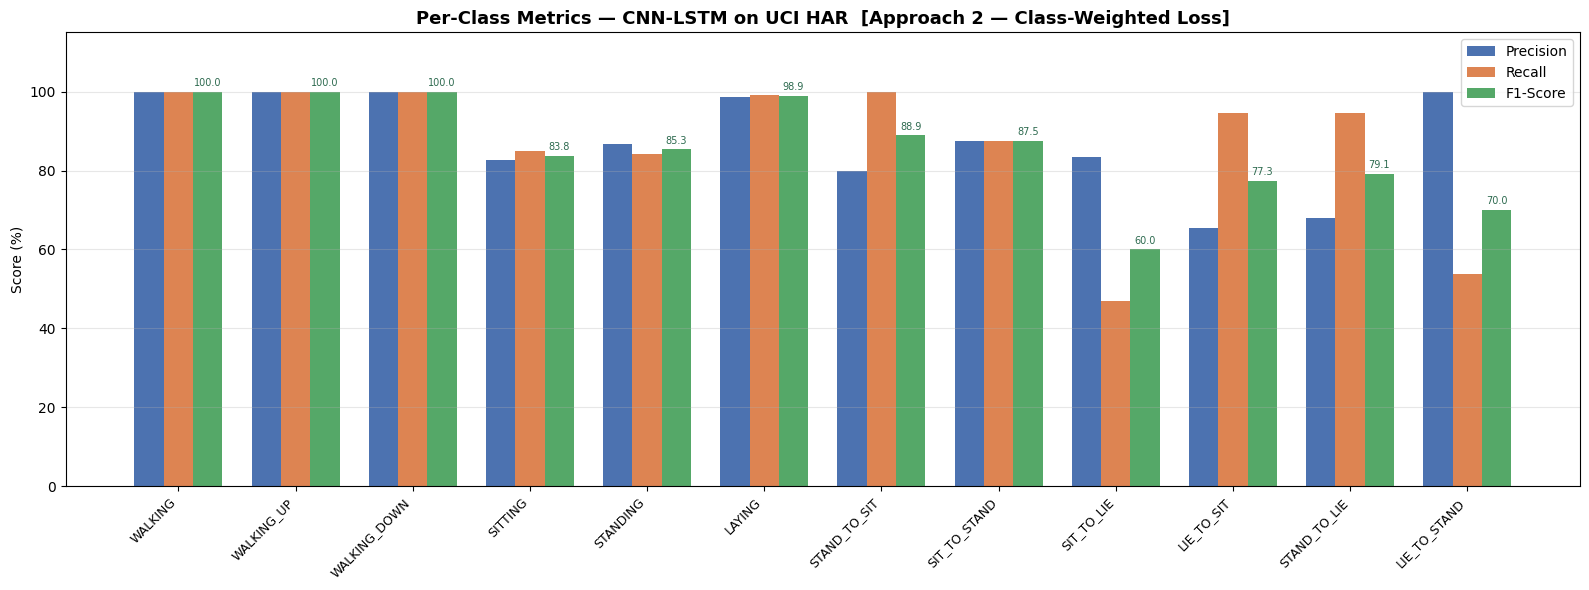

In [14]:
results_weighted = run_pipeline(
    use_smote=False,
    use_class_weights=True,
    X_train=X_train_norm, y_train=y_train_raw,
    X_test=X_test_norm,   y_test=y_test_raw,
    n_classes=n_classes,  class_names=class_names,
    title_suffix="[Approach 2 — Class-Weighted Loss]",
)


## Approach 3 — SMOTE

SMOTE equalises the training-set class distribution by synthesising new minority windows.


  Running: [Approach 3 — SMOTE + Class-Weighted Loss]
  SMOTE=True  |  Class weights=False

[SMOTE] Applying oversampling on training set ...
  Class distribution BEFORE SMOTE:
    WALKING        : 1437 windows
    WALKING_UP     : 1261 windows
    WALKING_DOWN   : 1130 windows
    SITTING        : 1682 windows
    STANDING       : 1785 windows
    LAYING         : 1829 windows
    STAND_TO_SIT   :  134 windows
    SIT_TO_STAND   :  104 windows
    SIT_TO_LIE     :  161 windows
    LIE_TO_SIT     :  152 windows
    STAND_TO_LIE   :  204 windows
    LIE_TO_STAND   :   94 windows
  Class distribution AFTER SMOTE:
    WALKING        : 1829 windows
    WALKING_UP     : 1829 windows
    WALKING_DOWN   : 1829 windows
    SITTING        : 1829 windows
    STANDING       : 1829 windows
    LAYING         : 1829 windows
    STAND_TO_SIT   : 1829 windows
    SIT_TO_STAND   : 1829 windows
    SIT_TO_LIE     : 1829 windows
    LIE_TO_SIT     : 1829 windows
    STAND_TO_LIE   : 1829 windows
    LI

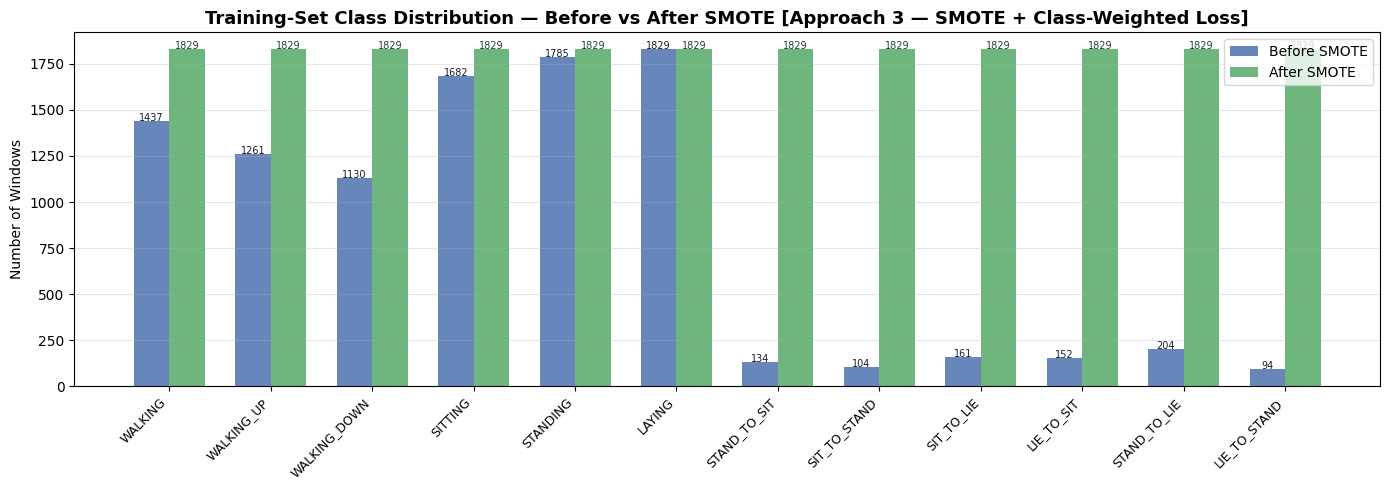

[Model] Trainable parameters: 312,012
[Train] Starting 100-epoch training ...
  Epoch   1/100 | Train loss 0.8075 acc 70.5% | Val loss 0.3631 acc 88.1%
  Epoch   5/100 | Train loss 0.2340 acc 91.3% | Val loss 0.3545 acc 90.1%
  Epoch  10/100 | Train loss 0.1631 acc 94.1% | Val loss 0.3359 acc 88.9%
  Epoch  15/100 | Train loss 0.1161 acc 95.8% | Val loss 0.3718 acc 91.2%
  Epoch  20/100 | Train loss 0.1024 acc 96.2% | Val loss 0.3658 acc 91.6%
  Epoch  25/100 | Train loss 0.0911 acc 96.8% | Val loss 0.3498 acc 89.6%
  Epoch  30/100 | Train loss 0.0778 acc 97.3% | Val loss 0.3615 acc 90.0%
  Epoch  35/100 | Train loss 0.0717 acc 97.3% | Val loss 0.3353 acc 93.0%
  Epoch  40/100 | Train loss 0.0670 acc 97.4% | Val loss 0.3272 acc 92.2%
  Epoch  45/100 | Train loss 0.0571 acc 97.8% | Val loss 0.3376 acc 92.4%
  Epoch  50/100 | Train loss 0.0509 acc 98.1% | Val loss 0.4138 acc 91.8%
  Epoch  55/100 | Train loss 0.0452 acc 98.3% | Val loss 0.3555 acc 92.7%
  Epoch  60/100 | Train loss 0.042

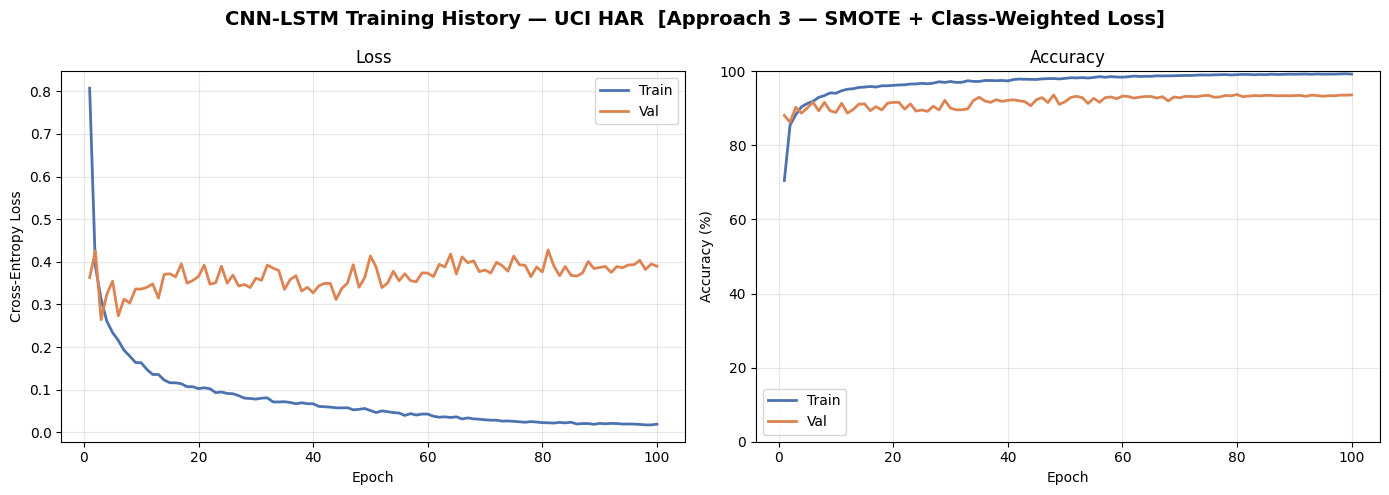

[Viz] Confusion matrix ...


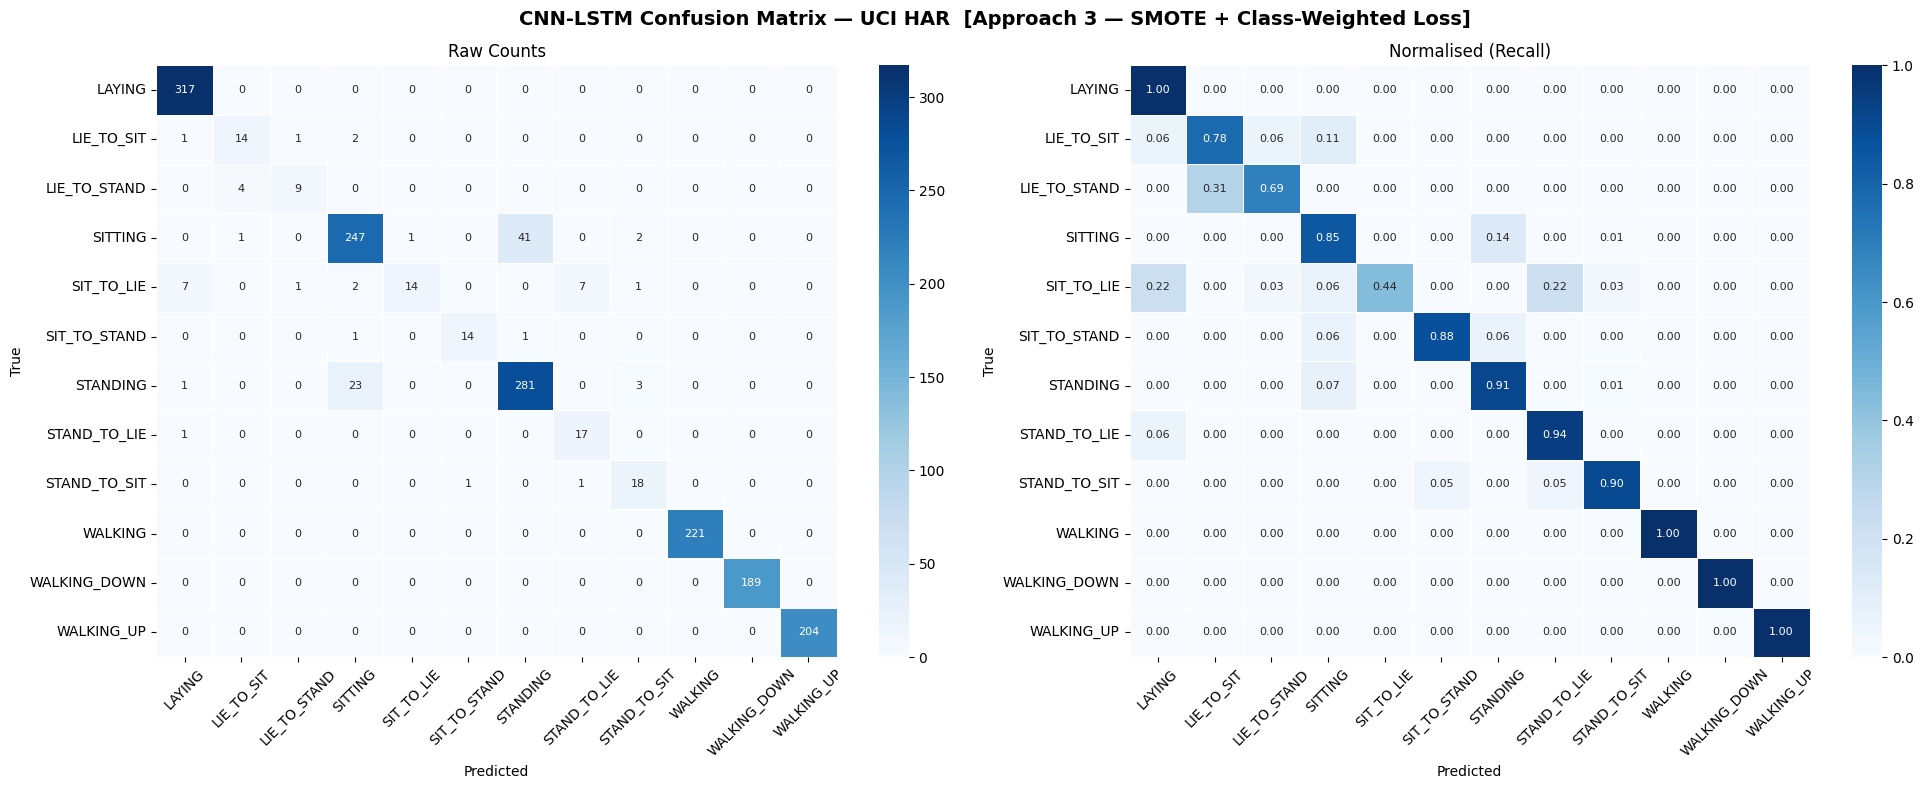

[Viz] MIoU ...


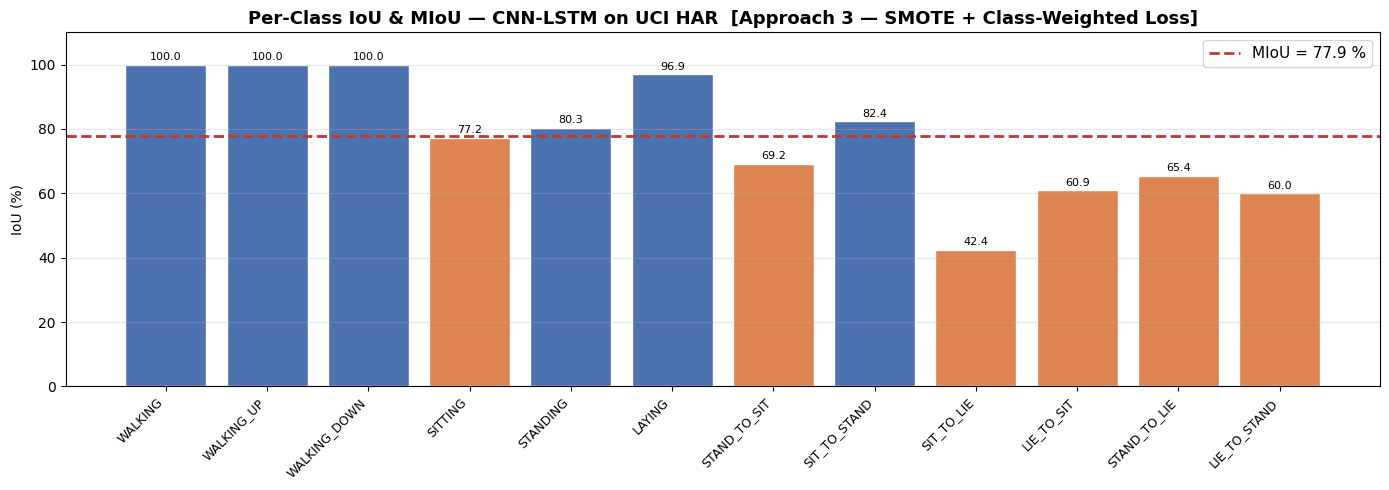

  MIoU : 77.89 %
    WALKING        : 100.0 %
    WALKING_UP     : 100.0 %
    WALKING_DOWN   : 100.0 %
    SITTING        : 77.2 %
    STANDING       : 80.3 %
    LAYING         : 96.9 %
    STAND_TO_SIT   : 69.2 %
    SIT_TO_STAND   : 82.4 %
    SIT_TO_LIE     : 42.4 %
    LIE_TO_SIT     : 60.9 %
    STAND_TO_LIE   : 65.4 %
    LIE_TO_STAND   : 60.0 %
[Viz] ROC-AUC (One-vs-Rest) ...


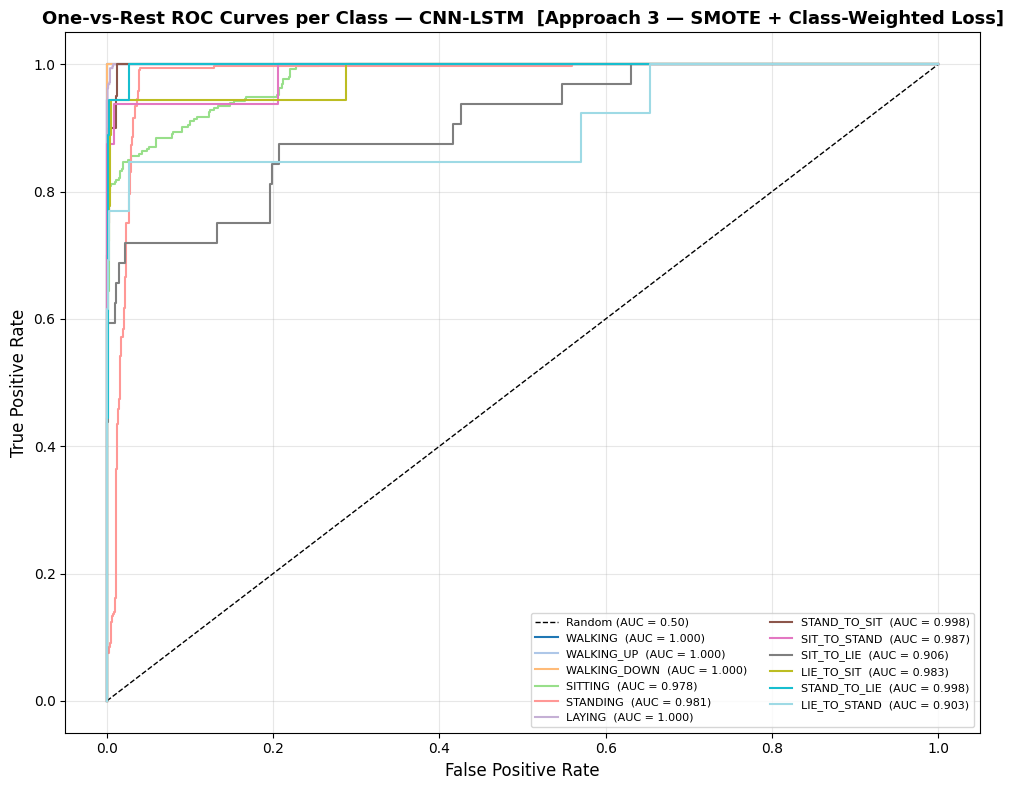

[Viz] Per-class precision / recall / F1 ...


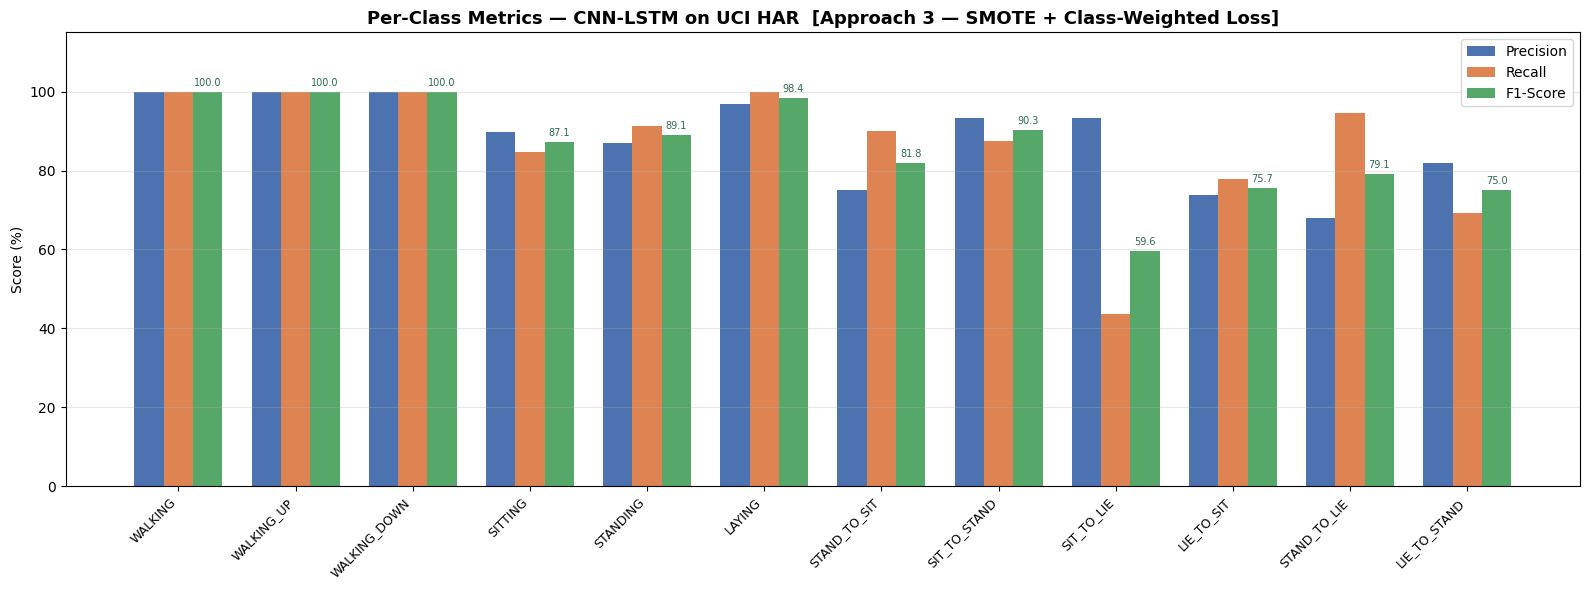

In [15]:
results_smote = run_pipeline(
    use_smote=True,
    use_class_weights=False,
    X_train=X_train_norm, y_train=y_train_raw,
    X_test=X_test_norm,   y_test=y_test_raw,
    n_classes=n_classes,  class_names=class_names,
    title_suffix="[Approach 3 — SMOTE + Class-Weighted Loss]",
)

### Summary — Approach Comparison

In [16]:
# Collect macro-average F1 and MIoU from each run for a clean summary table

from sklearn.metrics import f1_score, jaccard_score

def summarise(results, label):
    f1   = f1_score(results["true"], results["preds"], average="macro", zero_division=0)
    miou = jaccard_score(results["true"], results["preds"], average="macro", zero_division=0)
    return {
        "Approach":      label,
        "Test Acc (%)":  f"{results['final_acc'] * 100:.2f}",
        "Macro F1 (%)":  f"{f1 * 100:.2f}",
        "MIoU (%)":      f"{miou * 100:.2f}",
    }

rows = [
    summarise(results_baseline, "Baseline"),
    summarise(results_weighted, "Class-Weighted Loss"),
    summarise(results_smote,    "SMOTE + Class-Weighted Loss"),
]

print(f"{'Approach':<35} {'Test Acc':>10} {'Macro F1':>12} {'MIoU':>10}")
print("-" * 70)
for r in rows:
    print(f"{r['Approach']:<35} {r['Test Acc (%)']:>10} {r['Macro F1 (%)']:>12} {r['MIoU (%)']:>10}")


Approach                              Test Acc     Macro F1       MIoU
----------------------------------------------------------------------
Baseline                                 94.24        86.85      79.29
Class-Weighted Loss                      92.54        85.90      77.26
SMOTE + Class-Weighted Loss              93.75        86.34      77.89
